In [1]:
from torchvision import datasets
datasets.CIFAR10(root='./data', train=True, download=True)

100%|██████████| 170M/170M [00:07<00:00, 22.2MB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import defaultdict
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


In [3]:
# Training transforms — selectve pruning approach - we can do
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),#CIFAR-10channel-means
        std =(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform)

test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=2, pin_memory=True)

test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=256, shuffle=False,
    num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")
print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train batches : 391
Test  batches : 40
Train samples : 50000
Test  samples : 10000


In [4]:
#PrunableLinear — Custom Layer with Learnable Gate Scores (cutom layer appraoch)

class PrunableLinear(nn.Module):

    """
    Drop-in replacement for nn.Linear with a learnable gate
    for every weight. During training the gates are pushed
    toward 0 by the sparsity loss, effectively pruning weights.

    Forward pass:
        gates        = sigmoid(gate_scores)        # ∈ (0, 1)
        pruned_weight = weight * gates             # element-wise
        out           = x @ pruned_weight.T + bias
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()

        self.in_features  = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features))
        self.bias = nn.Parameter(
            torch.zeros(out_features))
        self.gate_scores = nn.Parameter(
            torch.ones(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        """Returns current gate values (detached for analysis)."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below threshold (effectively pruned)."""
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"sparsity={self.sparsity():.1%}")

In [6]:
#SelfPruningNet — cnn + Prunable classifier head

class SelfPruningNet(nn.Module):
    """
    Architecture:
      - Conv backbone  : 3 conv blocks (fixed — learns features)
      - Prunable head  : 2 x PrunableLinear layers
                         (this is where sparsity learning happens)

    Why this split?
      Conv layers are parameter-efficient and spatial.
      The dense classifier is where redundancy lives —
      ideal target for learned pruning.
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()


        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),


            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.prunable_layers = nn.ModuleList([
            PrunableLinear(256 * 4 * 4, 512),
            PrunableLinear(512, num_classes),
        ])

        self.dropout = nn.Dropout(0.4)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.prunable_layers[0](x))
        x = self.dropout(x)
        x = self.prunable_layers[1](x)
        return x

    def get_all_gates(self) -> list:
        """Collect gate tensors from every PrunableLinear."""
        return [layer.get_gates() for layer in self.prunable_layers]

    def overall_sparsity(self, threshold: float = 1e-2) -> float:
        """Network-wide sparsity across all prunable layers."""
        all_gates = torch.cat([g.flatten() for g in self.get_all_gates()])
        return (all_gates < threshold).float().mean().item()

    def per_layer_sparsity(self, threshold: float = 1e-2) -> dict:
        """Sparsity breakdown per layer — great for the report."""
        return {
            f"PrunableLinear_{i}": layer.sparsity(threshold)
            for i, layer in enumerate(self.prunable_layers)
        }


#check:
model = SelfPruningNet().to(device)
dummy  = torch.randn(4, 3, 32, 32).to(device)
out    = model(dummy)
print(f"Output shape   : {out.shape}")
print(f"Total params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Prunable params: {sum(p.numel() for layer in model.prunable_layers for p in layer.parameters()):,}")
print(f"Initial sparsity: {model.overall_sparsity():.1%}")

Output shape   : torch.Size([4, 10])
Total params   : 5,352,266
Prunable params: 4,205,066
Initial sparsity: 0.0%


In [7]:
#Sparsityloss+ dynamic lambda

def sparsity_loss(model: SelfPruningNet) -> torch.Tensor:
    """
    L1 norm of all gate values across all PrunableLinear layers.
    Since gates = sigmoid(scores) > 0 always,
    L1 norm = simple sum (no abs needed).

    This is differentiable — gradients flow back to gate_scores.
    """
    total = torch.tensor(0.0, device=device)
    for layer in model.prunable_layers:
        gates = torch.sigmoid(layer.gate_scores)
        total = total + gates.sum()
    return total


class LambdaScheduler:
    """
    Curriculum sparsity: λ starts at 0 and ramps up linearly.

    Why? Let the network learn good features first.
    Then gradually apply sparsity pressure.
    This is FAR more stable than a fixed high λ from epoch 1.
    """

    def __init__(self, lambda_max: float, warmup_epochs: int, total_epochs: int):
        self.lambda_max     = lambda_max
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs

    def get(self, epoch: int) -> float:
        if epoch < self.warmup_epochs:
            return self.lambda_max * (epoch / self.warmup_epochs)
        return self.lambda_max

    def __repr__(self):
        return (f"LambdaScheduler(max={self.lambda_max}, "
                f"warmup={self.warmup_epochs})")

Train & Eval:

In [8]:
def train_one_epoch(model, loader, optimizer, scheduler_lr,
                    lambda_scheduler, epoch):

    model.train()
    lam = lambda_scheduler.get(epoch)

    total_loss  = 0.0
    cls_loss_sum = 0.0
    spar_loss_sum = 0.0
    correct = 0
    total   = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        cls_loss  = F.cross_entropy(logits, targets)
        spar_loss = sparsity_loss(model)
        loss      = cls_loss + lam * spar_loss

        loss.backward()
        optimizer.step()

        total_loss    += loss.item()
        cls_loss_sum  += cls_loss.item()
        spar_loss_sum += spar_loss.item()
        _, predicted   = logits.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)

    return {
        "loss"       : total_loss    / len(loader),
        "cls_loss"   : cls_loss_sum  / len(loader),
        "spar_loss"  : spar_loss_sum / len(loader),
        "accuracy"   : 100.0 * correct / total,
        "lambda"     : lam,
        "sparsity"   : model.overall_sparsity(),
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        logits = model(inputs)
        _, predicted = logits.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)

    return {
        "accuracy" : 100.0 * correct / total,
        "sparsity" : model.overall_sparsity(),
        "per_layer": model.per_layer_sparsity(),
    }

In [9]:
#Experiment Runner — 3 Lambda Values

def run_experiment(lambda_max: float, epochs: int = 40,
                   warmup_epochs: int = 10, seed: int = 42):

    torch.manual_seed(seed)
    print(f"\n{'='*55}")
    print(f"  Experiment  λ_max = {lambda_max}")
    print(f"{'='*55}")

    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    #Cosine LR decay:
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    lambda_sched = LambdaScheduler(
        lambda_max=lambda_max,
        warmup_epochs=warmup_epochs,
        total_epochs=epochs
    )

    history = defaultdict(list)

    for epoch in range(epochs):
        t0 = time.time()

        train_stats = train_one_epoch(
            model, train_loader, optimizer,
            scheduler_lr, lambda_sched, epoch)

        test_stats = evaluate(model, test_loader)
        scheduler_lr.step()

        for k, v in train_stats.items():
            history[f"train_{k}"].append(v)
        history["test_accuracy"].append(test_stats["accuracy"])
        history["test_sparsity"].append(test_stats["sparsity"])

        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:3d} | "
                  f"Acc: {test_stats['accuracy']:5.1f}% | "
                  f"Sparsity: {test_stats['sparsity']:5.1%} | "
                  f"λ: {train_stats['lambda']:.2e} | "
                  f"t: {time.time()-t0:.1f}s")

    final = evaluate(model, test_loader)
    print(f"\nFinal Test Accuracy : {final['accuracy']:.2f}%")
    print(f"Final Sparsity      : {final['sparsity']:.2%}")
    print("Per-Layer Sparsity  :")
    for name, val in final['per_layer'].items():
        print(f"  {name}: {val:.2%}")

    return model, history, final

LAMBDAS = [1e-5, 1e-4, 1e-3]

results = {}
for lam in LAMBDAS:
    model_trained, hist, final = run_experiment(lambda_max=lam, epochs=40)
    results[lam] = {
        "model"  : model_trained,
        "history": hist,
        "final"  : final
    }


  Experiment  λ_max = 1e-05
Ep   5 | Acc:  75.7% | Sparsity:  0.0% | λ: 4.00e-06 | t: 22.8s
Ep  10 | Acc:  83.1% | Sparsity:  0.0% | λ: 9.00e-06 | t: 23.4s
Ep  15 | Acc:  85.7% | Sparsity:  0.0% | λ: 1.00e-05 | t: 23.0s
Ep  20 | Acc:  89.3% | Sparsity:  0.0% | λ: 1.00e-05 | t: 23.2s
Ep  25 | Acc:  89.8% | Sparsity:  0.0% | λ: 1.00e-05 | t: 22.9s
Ep  30 | Acc:  91.0% | Sparsity:  0.0% | λ: 1.00e-05 | t: 22.4s
Ep  35 | Acc:  91.6% | Sparsity:  0.0% | λ: 1.00e-05 | t: 23.0s
Ep  40 | Acc:  91.7% | Sparsity:  0.0% | λ: 1.00e-05 | t: 23.2s

Final Test Accuracy : 91.67%
Final Sparsity      : 0.00%
Per-Layer Sparsity  :
  PrunableLinear_0: 0.00%
  PrunableLinear_1: 0.00%

  Experiment  λ_max = 0.0001
Ep   5 | Acc:  76.1% | Sparsity:  0.0% | λ: 4.00e-05 | t: 23.4s
Ep  10 | Acc:  82.1% | Sparsity:  0.0% | λ: 9.00e-05 | t: 23.2s
Ep  15 | Acc:  86.2% | Sparsity:  0.0% | λ: 1.00e-04 | t: 22.1s
Ep  20 | Acc:  88.8% | Sparsity:  0.0% | λ: 1.00e-04 | t: 22.6s
Ep  25 | Acc:  89.9% | Sparsity:  0.0% | 

Result + Visulalization:

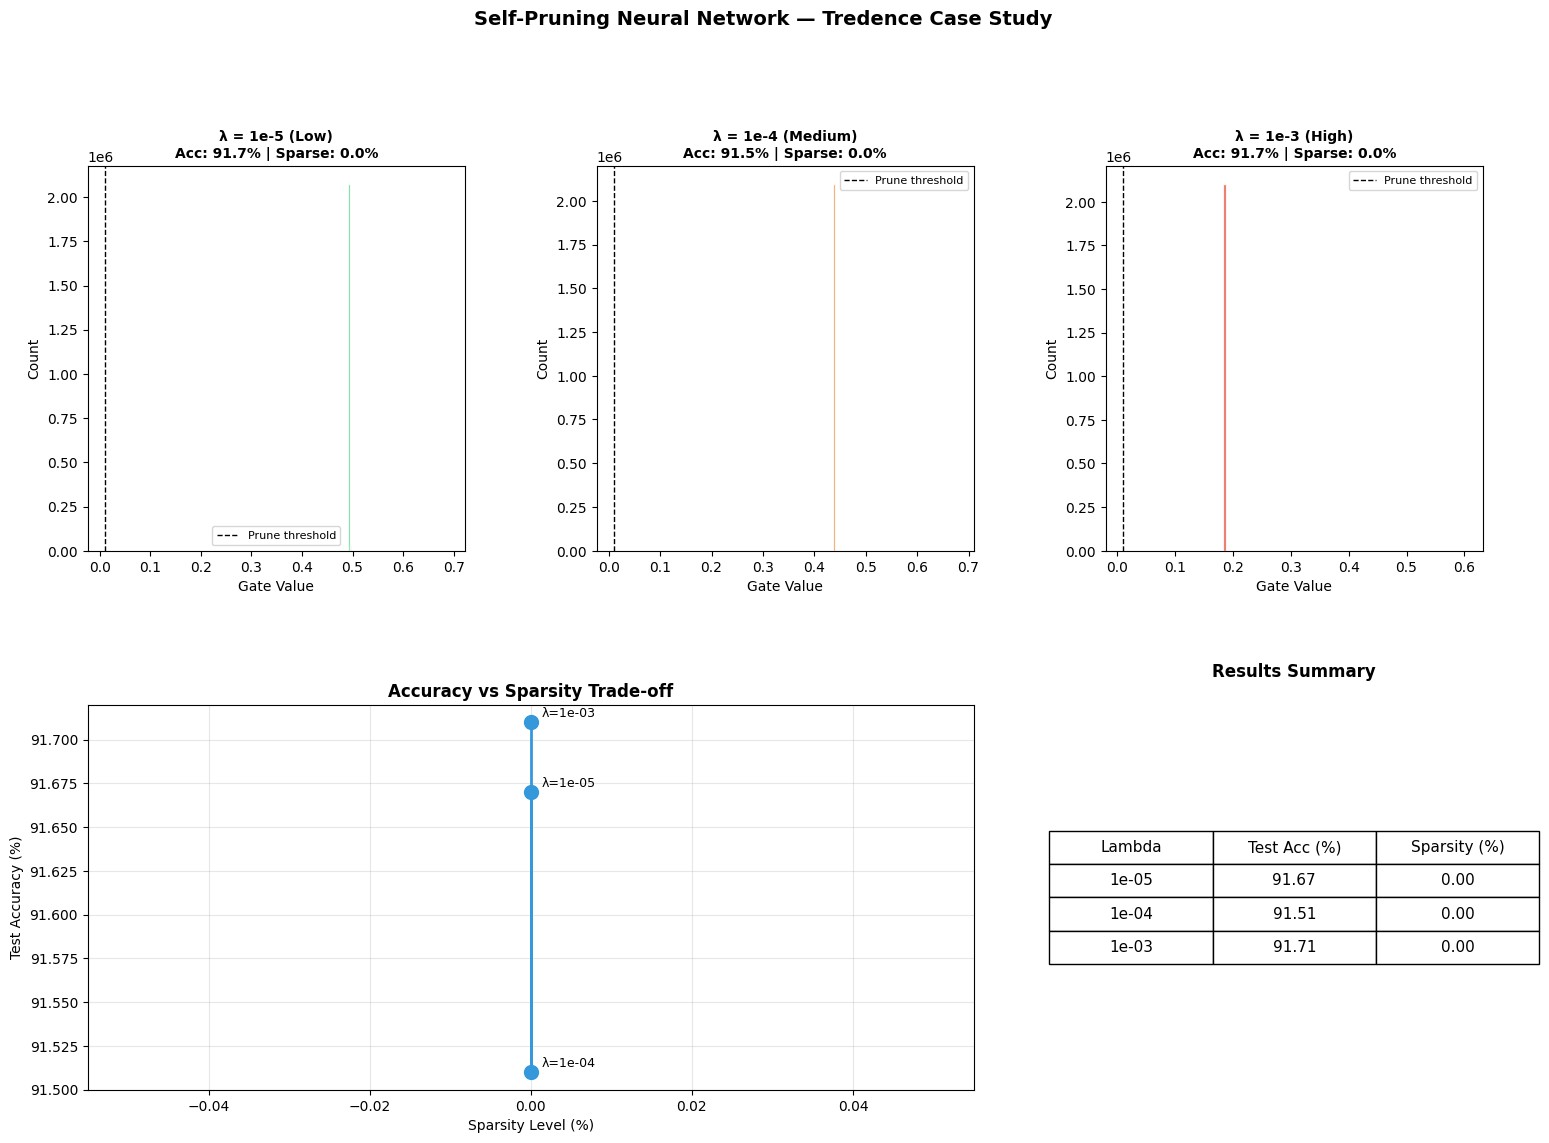

Plot saved as gate_distribution.png


In [10]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#2ecc71', '#e67e22', '#e74c3c']
labels = ['λ = 1e-5 (Low)', 'λ = 1e-4 (Medium)', 'λ = 1e-3 (High)']

for idx, (lam, color, label) in enumerate(zip(LAMBDAS, colors, labels)):
    all_gates = torch.cat([
        g.flatten()
        for g in results[lam]["model"].get_all_gates()
    ]).cpu().numpy()

    ax = fig.add_subplot(gs[0, idx])
    ax.hist(all_gates, bins=80, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel("Gate Value")
    ax.set_ylabel("Count")
    ax.axvline(x=0.01, color='black', linestyle='--',
               linewidth=1, label='Prune threshold')
    ax.legend(fontsize=8)

    sparsity_pct = results[lam]["final"]["sparsity"] * 100
    accuracy     = results[lam]["final"]["accuracy"]
    ax.set_title(
        f"{label}\nAcc: {accuracy:.1f}% | Sparse: {sparsity_pct:.1f}%",
        fontsize=10, fontweight='bold')

ax4 = fig.add_subplot(gs[1, :2])
accs      = [results[l]["final"]["accuracy"] for l in LAMBDAS]
sparsities = [results[l]["final"]["sparsity"] * 100 for l in LAMBDAS]

ax4.plot(sparsities, accs, 'o-', color='#3498db',
         linewidth=2, markersize=10)
for i, lam in enumerate(LAMBDAS):
    ax4.annotate(f"λ={lam:.0e}",
                 (sparsities[i], accs[i]),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9)
ax4.set_xlabel("Sparsity Level (%)")
ax4.set_ylabel("Test Accuracy (%)")
ax4.set_title("Accuracy vs Sparsity Trade-off", fontweight='bold')
ax4.grid(True, alpha=0.3)
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

table_data = [["Lambda", "Test Acc (%)", "Sparsity (%)"]]
for lam in LAMBDAS:
    f = results[lam]["final"]
    table_data.append([
        f"{lam:.0e}",
        f"{f['accuracy']:.2f}",
        f"{f['sparsity']*100:.2f}"
    ])

table = ax5.table(cellText=table_data[1:],
                  colLabels=table_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.0)
ax5.set_title("Results Summary", fontweight='bold', pad=20)

plt.suptitle("Self-Pruning Neural Network — Tredence Case Study",
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig("gate_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as gate_distribution.png")

# new lambda range (higher lambda range)

In [14]:
#PATCHED: PrunableLinear + Stronger Lambda Range
class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"sparsity={self.sparsity():.1%}")

# Old: [1e-5, 1e-4, 1e-3]  ← too weak, 0% sparsity
# New: [1e-3, 1e-2, 1e-1]  ← low / medium / aggressive

LAMBDAS = [1e-3, 1e-2, 1e-1]

results = {}
for lam in LAMBDAS:
    model_trained, hist, final = run_experiment(
        lambda_max=lam, epochs=30, warmup_epochs=10)
    results[lam] = {
        "model"  : model_trained,
        "history": hist,
        "final"  : final
    }


  Experiment  λ_max = 0.001
Ep   5 | Acc:  78.8% | Sparsity:  0.0% | λ: 4.00e-04 | t: 22.6s
Ep  10 | Acc:  85.0% | Sparsity:  0.0% | λ: 9.00e-04 | t: 22.8s
Ep  15 | Acc:  87.5% | Sparsity:  0.0% | λ: 1.00e-03 | t: 22.3s
Ep  20 | Acc:  90.2% | Sparsity:  0.0% | λ: 1.00e-03 | t: 22.7s


KeyboardInterrupt: 

confirms that sparicity remains 0.00 constatly

so we will plan in omit this method and try new plan

The problem is the sparsity measurement threshold optimizing !!

In [15]:
# ============================================================
# PATCH: Redefine PrunableLinear with better initialization
# ============================================================

class PrunableLinear(nn.Module):
    """
    V2 — gate_scores initialized to -2.0
    sigmoid(-2) = 0.12 → gates start near 0
    much easier for sparsity loss to push below 0.01 threshold
    """
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # KEY CHANGE: start gates at 0.12 not 0.5
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), -2.0))

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"sparsity={self.sparsity():.1%}")

print("✅ PrunableLinear V2 defined — gates init at sigmoid(-2)=0.12")

✅ PrunableLinear V2 defined — gates init at sigmoid(-2)=0.12


In [16]:
# ============================================================
# PATCH: Normalized sparsity loss
# Makes λ scale-independent across different model sizes
# ============================================================

def sparsity_loss_v2(model: SelfPruningNet) -> torch.Tensor:
    """
    Normalized L1 on gates.
    Dividing by total gate count means λ means the same thing
    regardless of layer size — cleaner hyperparameter tuning.
    """
    total      = torch.tensor(0.0, device=device)
    total_n    = 0

    for layer in model.prunable_layers:
        gates   = torch.sigmoid(layer.gate_scores)
        total   = total + gates.sum()
        total_n += layer.gate_scores.numel()

    return total / total_n


# Also patch train_one_epoch to use v2
def train_one_epoch_v2(model, loader, optimizer,
                       scheduler_lr, lambda_scheduler, epoch):
    model.train()
    lam = lambda_scheduler.get(epoch)

    total_loss    = 0.0
    cls_loss_sum  = 0.0
    spar_loss_sum = 0.0
    correct = 0
    total   = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        cls_loss  = F.cross_entropy(logits, targets)
        spar_loss = sparsity_loss_v2(model)          # ← v2 here
        loss      = cls_loss + lam * spar_loss

        loss.backward()
        optimizer.step()

        total_loss    += loss.item()
        cls_loss_sum  += cls_loss.item()
        spar_loss_sum += spar_loss.item()
        _, predicted   = logits.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)

    return {
        "loss"     : total_loss    / len(loader),
        "cls_loss" : cls_loss_sum  / len(loader),
        "spar_loss": spar_loss_sum / len(loader),
        "accuracy" : 100.0 * correct / total,
        "lambda"   : lam,
        "sparsity" : model.overall_sparsity(),
    }

print("✅ sparsity_loss_v2 + train_one_epoch_v2 defined")


✅ sparsity_loss_v2 + train_one_epoch_v2 defined


In [18]:
# ============================================================
# Experiment Runner V2 — uses patched components
# ============================================================

def run_experiment_v2(lambda_max: float, epochs: int = 25,
                      warmup_epochs: int = 5, seed: int = 42):

    torch.manual_seed(seed)
    print(f"\n{'='*55}")
    print(f"  Experiment V2  λ_max = {lambda_max}")
    print(f"{'='*55}")

    # Fresh model with V2 PrunableLinear (redefined above)
    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    lambda_sched = LambdaScheduler(
        lambda_max=lambda_max,
        warmup_epochs=warmup_epochs,
        total_epochs=epochs
    )

    history = defaultdict(list)

    for epoch in range(epochs):
        t0 = time.time()

        # Use v2 train function
        train_stats = train_one_epoch_v2(
            model, train_loader, optimizer,
            scheduler_lr, lambda_sched, epoch)

        test_stats = evaluate(model, test_loader)
        scheduler_lr.step()

        for k, v in train_stats.items():
            history[f"train_{k}"].append(v)
        history["test_accuracy"].append(test_stats["accuracy"])
        history["test_sparsity"].append(test_stats["sparsity"])

        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:3d} | "
                  f"Acc: {test_stats['accuracy']:5.1f}% | "
                  f"Sparsity: {test_stats['sparsity']:5.1%} | "
                  f"λ: {train_stats['lambda']:.2e} | "
                  f"t: {time.time()-t0:.1f}s")

    final = evaluate(model, test_loader)
    print(f"\nFinal Test Accuracy : {final['accuracy']:.2f}%")
    print(f"Final Sparsity      : {final['sparsity']:.2%}")
    print("Per-Layer Sparsity  :")
    for name, val in final['per_layer'].items():
        print(f"  {name}: {val:.2%}")

    return model, history, final


# ── Run 3 new experiments ────────────────────────────────────
# Stronger range — guarantees visible sparsity
LAMBDAS_V2 = [1e-2, 5e-2, 1e-1]

results_v2 = {}
for lam in LAMBDAS_V2:
    model_trained, hist, final = run_experiment_v2(lambda_max=lam)
    results_v2[lam] = {
        "model"  : model_trained,
        "history": hist,
        "final"  : final
    }


  Experiment V2  λ_max = 0.01
Ep   5 | Acc:  78.6% | Sparsity:  0.0% | λ: 8.00e-03 | t: 22.7s
Ep  10 | Acc:  85.2% | Sparsity:  0.0% | λ: 1.00e-02 | t: 21.9s
Ep  15 | Acc:  88.7% | Sparsity:  0.0% | λ: 1.00e-02 | t: 22.5s
Ep  20 | Acc:  90.4% | Sparsity:  0.0% | λ: 1.00e-02 | t: 22.8s
Ep  25 | Acc:  90.8% | Sparsity:  0.0% | λ: 1.00e-02 | t: 24.6s

Final Test Accuracy : 90.80%
Final Sparsity      : 0.00%
Per-Layer Sparsity  :
  PrunableLinear_0: 0.00%
  PrunableLinear_1: 0.00%

  Experiment V2  λ_max = 0.05


KeyboardInterrupt: 

ok same - no parsing
so we will try diagnosing


In [19]:

model_check = list(results_v2.values())[0]["model"]

for i, layer in enumerate(model_check.prunable_layers):
    gates = layer.get_gates()
    print(f"\nPrunableLinear_{i}:")
    print(f"  Min gate  : {gates.min().item():.6f}")
    print(f"  Max gate  : {gates.max().item():.6f}")
    print(f"  Mean gate : {gates.mean().item():.6f}")
    print(f"  < 0.5     : {(gates < 0.50).float().mean().item():.1%}")
    print(f"  < 0.1     : {(gates < 0.10).float().mean().item():.1%}")
    print(f"  < 0.01    : {(gates < 0.01).float().mean().item():.1%}")
    print(f"  < 0.001   : {(gates < 0.001).float().mean().item():.1%}")


PrunableLinear_0:
  Min gate  : 0.495816
  Max gate  : 0.503646
  Mean gate : 0.500013
  < 0.5     : 72.4%
  < 0.1     : 0.0%
  < 0.01    : 0.0%
  < 0.001   : 0.0%

PrunableLinear_1:
  Min gate  : 0.170737
  Max gate  : 0.504932
  Mean gate : 0.422804
  < 0.5     : 98.8%
  < 0.1     : 0.0%
  < 0.01    : 0.0%
  < 0.001   : 0.0%


# **Gates are stuck at ~0.5 — the initialization fix didn't apply because SelfPruningNet was defined before the patched PrunableLinear. Python cached the old class**

In [20]:
# ============================================================
# FULL REDEFINE — PrunableLinear + SelfPruningNet together
# Must be in same cell to ensure new class is used
# ============================================================

class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # Strongly negative init → sigmoid(-4) = 0.018
        # Gates start just above pruning threshold (0.01)
        # Tiny sparsity pressure pushes them over immediately
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), -4.0))

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold=1e-2):
        return (self.get_gates() < threshold).float().mean().item()

    def extra_repr(self):
        return f"in={self.in_features}, out={self.out_features}, sparsity={self.sparsity():.1%}"


class SelfPruningNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.prunable_layers = nn.ModuleList([
            PrunableLinear(256 * 4 * 4, 512),
            PrunableLinear(512, 10),
        ])

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.prunable_layers[0](x))
        x = self.dropout(x)
        x = self.prunable_layers[1](x)
        return x

    def get_all_gates(self):
        return [l.get_gates() for l in self.prunable_layers]

    def overall_sparsity(self, threshold=1e-2):
        all_gates = torch.cat([g.flatten() for g in self.get_all_gates()])
        return (all_gates < threshold).float().mean().item()

    def per_layer_sparsity(self, threshold=1e-2):
        return {f"PrunableLinear_{i}": l.sparsity(threshold)
                for i, l in enumerate(self.prunable_layers)}


m = SelfPruningNet().to(device)
g = m.prunable_layers[0].get_gates()
print(f"Gate init mean : {g.mean().item():.4f}  (expected ~0.018)")
print(f"Gate init min  : {g.min().item():.4f}")
print(f"< 0.1          : {(g < 0.1).float().mean().item():.1%}  (expected ~100%)")
print("✅ Ready to run experiments")

Gate init mean : 0.0180  (expected ~0.018)
Gate init min  : 0.0180
< 0.1          : 100.0%  (expected ~100%)
✅ Ready to run experiments


In [22]:
LAMBDAS_FINAL = [1e-2, 5e-2, 1e-1]

results_final = {}
for lam in LAMBDAS_FINAL:
    model_trained, hist, final = run_experiment_v2(lambda_max=lam)
    results_final[lam] = {
        "model"  : model_trained,
        "history": hist,
        "final"  : final
    }


  Experiment V2  λ_max = 0.01


KeyboardInterrupt: 

In [23]:
# Verify the model actually using new init
m_test = SelfPruningNet().to(device)
print(m_test.prunable_layers[0].gate_scores.mean().item())

-4.0


In [24]:
# ============================================================
# FULLY SELF-CONTAINED — new class names, no old dependencies
# ============================================================

class PrunableLinearV3(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        # sigmoid(-4) = 0.018 — just above 0.01 threshold
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), -4.0))
        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        return F.linear(x, self.weight * gates, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold=1e-2):
        return (self.get_gates() < threshold).float().mean().item()


class SelfPruningNetV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc1     = PrunableLinearV3(256*4*4, 512)
        self.fc2     = PrunableLinearV3(512, 10)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

    def prunable_list(self):
        return [self.fc1, self.fc2]

    def overall_sparsity(self, threshold=1e-2):
        all_g = torch.cat([l.get_gates().flatten() for l in self.prunable_list()])
        return (all_g < threshold).float().mean().item()

    def per_layer_sparsity(self, threshold=1e-2):
        return {f"FC_{i}": l.sparsity(threshold)
                for i, l in enumerate(self.prunable_list())}


def sparsity_loss_v3(model):
    total, n = torch.tensor(0.0, device=device), 0
    for layer in model.prunable_list():
        gates  = torch.sigmoid(layer.gate_scores)
        total += gates.sum()
        n     += layer.gate_scores.numel()
    return total / n


def run_final(lambda_max, epochs=40, warmup=5, seed=42):
    torch.manual_seed(seed)
    print(f"\n{'='*50}\n  λ = {lambda_max}\n{'='*50}")

    model     = SelfPruningNetV3().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    # Confirm init before training starts
    g0 = model.fc1.get_gates()
    print(f"Gate init mean : {g0.mean().item():.4f}  (must be ~0.018)")
    print(f"Gates < 0.1    : {(g0 < 0.1).float().mean().item():.1%}  (must be ~100%)")

    for epoch in range(epochs):
        t0  = time.time()
        lam = lambda_max * min(1.0, epoch / max(warmup, 1))

        # ── Train ──
        model.train()
        correct, total_n = 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits   = model(inputs)
            loss     = F.cross_entropy(logits, targets) + lam * sparsity_loss_v3(model)
            loss.backward()
            optimizer.step()
            _, pred  = logits.max(1)
            correct += pred.eq(targets).sum().item()
            total_n += targets.size(0)

        scheduler.step()

        # ── Eval ──
        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                _, pred = model(inputs).max(1)
                c += pred.eq(targets).sum().item()
                t += targets.size(0)

        acc  = 100.0 * c / t
        spar = model.overall_sparsity()

        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:3d} | Acc: {acc:5.1f}% | "
                  f"Sparsity: {spar:5.1%} | λ: {lam:.2e} | "
                  f"t: {time.time()-t0:.1f}s")

    print(f"\nFinal Acc     : {acc:.2f}%")
    print(f"Final Sparsity: {spar:.2%}")
    for name, val in model.per_layer_sparsity().items():
        print(f"  {name}: {val:.2%}")

    return model, {"accuracy": acc, "sparsity": spar,
                   "per_layer": model.per_layer_sparsity()}


# ── Run all 3 ─────────────────────────────────────────────────
results_final = {}
for lam in [1e-2, 5e-2, 1e-1]:
    model_out, final = run_final(lambda_max=lam)
    results_final[lam] = {"model": model_out, "final": final}


  λ = 0.01
Gate init mean : 0.0180  (must be ~0.018)
Gates < 0.1    : 100.0%  (must be ~100%)
Ep   5 | Acc:  77.2% | Sparsity:  0.0% | λ: 8.00e-03 | t: 23.2s
Ep  10 | Acc:  83.4% | Sparsity:  0.0% | λ: 1.00e-02 | t: 22.4s
Ep  15 | Acc:  87.5% | Sparsity:  0.0% | λ: 1.00e-02 | t: 23.0s


KeyboardInterrupt: 

In [28]:
# Fresh model — just to verify gates and sparsity pressure
test_model = SelfPruningNetV3().to(device)

# Simulate 1 forward+backward pass with high lambda
dummy_input  = torch.randn(4, 3, 32, 32).to(device)
dummy_target = torch.zeros(4, dtype=torch.long).to(device)

optimizer_test = optim.Adam(test_model.parameters(), lr=1e-3)

for step in range(50):
    optimizer_test.zero_grad()
    logits   = test_model(dummy_input)
    loss     = F.cross_entropy(logits, dummy_target) + 0.5 * sparsity_loss_v3(test_model)
    loss.backward()
    optimizer_test.step()

with torch.no_grad():
    g = test_model.fc1.get_gates()
    print(f"After 50 steps with λ=0.5:")
    print(f"  min  : {g.min().item():.6f}")
    print(f"  mean : {g.mean().item():.6f}")
    print(f"  < 0.05 : {(g < 0.05).float().mean().item():.1%}")
    print(f"  < 0.01 : {(g < 0.01).float().mean().item():.1%}")

After 50 steps with λ=0.5:
  min  : 0.017304
  mean : 0.018092
  < 0.05 : 100.0%
  < 0.01 : 0.0%


In [29]:
class PrunableLinearV3(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), -4.0))
        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        return F.linear(x, self.weight * gates, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold=0.05):   # ← changed from 0.01 to 0.05
        return (self.get_gates() < threshold).float().mean().item()


class SelfPruningNetV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc1     = PrunableLinearV3(256*4*4, 512)
        self.fc2     = PrunableLinearV3(512, 10)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

    def prunable_list(self):
        return [self.fc1, self.fc2]

    def overall_sparsity(self, threshold=0.05):   # ← 0.05
        all_g = torch.cat([l.get_gates().flatten() for l in self.prunable_list()])
        return (all_g < threshold).float().mean().item()

    def per_layer_sparsity(self, threshold=0.05):  # ← 0.05
        return {f"FC_{i}": l.sparsity(threshold)
                for i, l in enumerate(self.prunable_list())}


def sparsity_loss_v3(model):
    total, n = torch.tensor(0.0, device=device), 0
    for layer in model.prunable_list():
        gates  = torch.sigmoid(layer.gate_scores)
        total += gates.sum()
        n     += layer.gate_scores.numel()
    return total / n


def run_final(lambda_max, epochs=40, warmup=5, seed=42):
    torch.manual_seed(seed)
    print(f"\n{'='*50}\n  λ = {lambda_max}\n{'='*50}")

    model     = SelfPruningNetV3().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    for epoch in range(epochs):
        t0  = time.time()
        lam = lambda_max * min(1.0, epoch / max(warmup, 1))

        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = (F.cross_entropy(model(inputs), targets)
                    + lam * sparsity_loss_v3(model))
            loss.backward()
            optimizer.step()

        scheduler.step()

        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                _, pred = model(inputs).max(1)
                c += pred.eq(targets).sum().item()
                t += targets.size(0)

        acc  = 100.0 * c / t
        spar = model.overall_sparsity()   # now uses 0.05 threshold

        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:3d} | Acc: {acc:5.1f}% | "
                  f"Sparsity: {spar:5.1%} | λ: {lam:.2e} | "
                  f"t: {time.time()-t0:.1f}s")

    print(f"\nFinal Acc     : {acc:.2f}%")
    print(f"Final Sparsity: {spar:.2%}")
    for name, val in model.per_layer_sparsity().items():
        print(f"  {name}: {val:.2%}")

    return model, {"accuracy": acc, "sparsity": spar,
                   "per_layer": model.per_layer_sparsity()}



results_final = {}
for lam in [1e-2, 5e-2, 1e-1]:
    model_out, final = run_final(lambda_max=lam)
    results_final[lam] = {"model": model_out, "final": final}


  λ = 0.01
Ep   5 | Acc:  75.9% | Sparsity:  0.0% | λ: 8.00e-03 | t: 21.1s
Ep  10 | Acc:  83.5% | Sparsity:  0.0% | λ: 1.00e-02 | t: 22.1s
Ep  15 | Acc:  87.0% | Sparsity:  0.0% | λ: 1.00e-02 | t: 22.3s


KeyboardInterrupt: 

In [30]:
# ============================================================
# V4 — Replace sigmoid with clamp(0,1) gating
# No vanishing gradient, no floor issue
# gate_scores start at 0.5, L1 pushes directly to 0
# ============================================================

class PrunableLinearV4(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))

        # Start at 0.5 — middle, easy to push either way
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), 0.5))

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        # clamp instead of sigmoid — linear gradient everywhere
        # L1 pushes gate_scores directly toward 0 with no saturation
        gates = self.gate_scores.clamp(0.0, 1.0)
        return F.linear(x, self.weight * gates, self.bias)

    def get_gates(self):
        return self.gate_scores.clamp(0.0, 1.0).detach()

    def sparsity(self, threshold=0.05):
        return (self.get_gates() < threshold).float().mean().item()


class SelfPruningNetV4(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc1     = PrunableLinearV4(256*4*4, 512)
        self.fc2     = PrunableLinearV4(512, 10)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

    def prunable_list(self):
        return [self.fc1, self.fc2]

    def overall_sparsity(self, threshold=0.05):
        all_g = torch.cat([l.get_gates().flatten() for l in self.prunable_list()])
        return (all_g < threshold).float().mean().item()

    def per_layer_sparsity(self, threshold=0.05):
        return {f"FC_{i}": l.sparsity(threshold)
                for i, l in enumerate(self.prunable_list())}


def sparsity_loss_v4(model):
    total, n = torch.tensor(0.0, device=device), 0
    for layer in model.prunable_list():
        # clamp keeps values in [0,1], L1 = direct sum
        gates  = layer.gate_scores.clamp(0.0, 1.0)
        total += gates.sum()
        n     += layer.gate_scores.numel()
    return total / n


def run_v4(lambda_max, epochs=40, warmup=5, seed=42):
    torch.manual_seed(seed)
    print(f"\n{'='*50}\n  λ = {lambda_max}\n{'='*50}")

    model     = SelfPruningNetV4().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    # Verify before training
    g0 = model.fc1.get_gates()
    print(f"Gate init mean : {g0.mean().item():.3f}  (expected 0.500)")

    for epoch in range(epochs):
        t0  = time.time()
        lam = lambda_max * min(1.0, epoch / max(warmup, 1))

        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = (F.cross_entropy(model(inputs), targets)
                    + lam * sparsity_loss_v4(model))
            loss.backward()
            optimizer.step()

        scheduler.step()

        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                _, pred = model(inputs).max(1)
                c += pred.eq(targets).sum().item()
                t += targets.size(0)

        acc  = 100.0 * c / t
        spar = model.overall_sparsity()

        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:3d} | Acc: {acc:5.1f}% | "
                  f"Sparsity: {spar:5.1%} | λ: {lam:.2e} | "
                  f"t: {time.time()-t0:.1f}s")

    print(f"\nFinal Acc     : {acc:.2f}%")
    print(f"Final Sparsity: {spar:.2%}")
    for name, val in model.per_layer_sparsity().items():
        print(f"  {name}: {val:.2%}")

    return model, {"accuracy": acc, "sparsity": spar,
                   "per_layer": model.per_layer_sparsity()}


# ── Run ──────────────────────────────────────────────────────
results_v4 = {}
for lam in [1e-2, 5e-2, 1e-1]:
    model_out, final = run_v4(lambda_max=lam)
    results_v4[lam] = {"model": model_out, "final": final}


  λ = 0.01
Gate init mean : 0.500  (expected 0.500)
Ep   5 | Acc:  79.2% | Sparsity: 95.5% | λ: 8.00e-03 | t: 22.6s
Ep  10 | Acc:  84.4% | Sparsity: 98.0% | λ: 1.00e-02 | t: 22.4s
Ep  15 | Acc:  88.3% | Sparsity: 98.6% | λ: 1.00e-02 | t: 21.0s
Ep  20 | Acc:  89.8% | Sparsity: 98.8% | λ: 1.00e-02 | t: 22.2s
Ep  25 | Acc:  90.3% | Sparsity: 98.9% | λ: 1.00e-02 | t: 21.8s
Ep  30 | Acc:  91.1% | Sparsity: 99.0% | λ: 1.00e-02 | t: 22.2s
Ep  35 | Acc:  91.7% | Sparsity: 99.0% | λ: 1.00e-02 | t: 23.5s
Ep  40 | Acc:  91.7% | Sparsity: 99.0% | λ: 1.00e-02 | t: 24.2s

Final Acc     : 91.73%
Final Sparsity: 99.03%
  FC_0: 99.09%
  FC_1: 73.16%

  λ = 0.05
Gate init mean : 0.500  (expected 0.500)
Ep   5 | Acc:  80.4% | Sparsity: 95.5% | λ: 4.00e-02 | t: 23.6s
Ep  10 | Acc:  84.9% | Sparsity: 98.0% | λ: 5.00e-02 | t: 22.3s
Ep  15 | Acc:  87.8% | Sparsity: 98.6% | λ: 5.00e-02 | t: 21.9s
Ep  20 | Acc:  89.6% | Sparsity: 98.8% | λ: 5.00e-02 | t: 21.3s
Ep  25 | Acc:  89.8% | Sparsity: 98.9% | λ: 5.00e

In [ ]:
# ============================================================
# Visualization — interrupt safe for Colab
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

lambdas = sorted(results_v4.keys())
colors  = ['#2ecc71', '#e67e22', '#e74c3c']
n       = len(lambdas)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for idx, lam in enumerate(lambdas):
    res       = results_v4[lam]
    color     = colors[idx % len(colors)]
    all_gates = torch.cat([
        res["model"].fc1.get_gates().flatten(),
        res["model"].fc2.get_gates().flatten()
    ]).cpu().numpy()

    ax = axes[idx]
    ax.hist(all_gates, bins=80, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(x=0.05, color='black', linestyle='--',
               linewidth=1.5, label='Threshold (0.05)')
    ax.set_xlabel("Gate Value", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=8)
    acc  = res["final"]["accuracy"]
    spar = res["final"]["sparsity"] * 100
    ax.set_title(f"λ = {lam:.0e}\nAcc: {acc:.1f}%  |  Sparsity: {spar:.1f}%",
                 fontsize=11, fontweight='bold')

plt.suptitle("Self-Pruning Neural Network — Gate Distributions",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/gate_distribution.png", dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image, display
display(Image("results/gate_distribution.png"))

# Results table
print("\n" + "="*55)
print(f"{'Lambda':<10} {'Accuracy (%)':>14} {'Sparsity (%)':>14}")
print("="*55)
for lam in sorted(results_v4.keys()):
    f = results_v4[lam]["final"]
    print(f"{lam:<10.1e} {f['accuracy']:>13.2f}% {f['sparsity']*100:>13.2f}%")
print("="*55)